## Quality Metrics Table for Human Immune Health Atlas Metaprograms


In [22]:
import kaleidocell
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
from datetime import datetime

def checkpoint(msg):
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}", flush=True)

In [24]:
OUT_DIR = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/09_HIHAtlas"
os.makedirs(OUT_DIR, exist_ok=True)

adata = sc.read_h5ad("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/03_HIHAtlas/HIHAtlas_ds_TICAannot.h5ad")

In [4]:
checkpoint("Loading results_mp")
results_mp = kaleidocell.load("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/09_HIHAtlas/09_03_nmf_downsampled/results_mp_healthy.kc")
checkpoint(f"Loaded: {len(results_mp['mp_dict'])} MPs")

mp_dict = results_mp["mp_dict"]


[2026-08-27 10:54:20] Loading results_mp
[2026-08-27 10:54:20] Loaded: 8 MPs


In [5]:
checkpoint("Loading summary/metrics")
summary = results_mp["metrics"]
print(summary.columns.tolist())

checkpoint("Computing max_gene_score per MP")
summary["max_gene_score"] = pd.Series({mp: genes.max() for mp, genes in mp_dict.items()})

checkpoint("Loading meaningful_mps and computing n_pathways")
top_gsea_per_mp = pd.read_csv("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/09_HIHAtlas/09_03_nmf_downsampled/gsea_C7.csv")

n_pathways_per_mp = top_gsea_per_mp.groupby("MP")["Term"].nunique()
summary["n_pathways"] = summary.index.map(n_pathways_per_mp).fillna(0)

meaningful_mps = top_gsea_per_mp["MP"].unique()

[2026-08-27 10:56:04] Loading summary/metrics
['sampleCoverage', 'silhouette', 'meanSimilarity', 'nPrograms', 'nGenes']
[2026-08-27 10:56:04] Computing max_gene_score per MP
[2026-08-27 10:56:04] Loading meaningful_mps and computing n_pathways


In [13]:
print(mp_dict["MP8"].index.tolist()[:20])  # eyeball the actual gene name format

['ENSG00000188536', 'ENSG00000090382', 'ENSG00000244734', 'ENSG00000204472', 'ENSG00000127152', 'ENSG00000173457', 'ENSG00000206172', 'ENSG00000196735', 'ENSG00000090013', 'ENSG00000204482', 'ENSG00000230590', 'ENSG00000025708', 'ENSG00000132514', 'ENSG00000179344', 'ENSG00000128040', 'ENSG00000168685', 'ENSG00000211895', 'ENSG00000081059', 'ENSG00000117602', 'ENSG00000147454']


In [54]:
metrics_higher_better = ["silhouette", "max_gene_score", "n_pathways", "sampleCoverage", "meanSimilarity"]

flag_cols = {}
for col in metrics_higher_better:
    if col == "n_pathways":
        flag_cols[col] = summary[col] == 0
    else:
        flag_cols[col] = pd.Series(False, index=summary.index)

MT_GENE_MAP = {
    "ENSG00000198888": "MT-ND1",
    "ENSG00000198763": "MT-ND2",
    "ENSG00000198804": "MT-CO1",
    "ENSG00000198712": "MT-CO2",
    "ENSG00000228253": "MT-ATP8",
    "ENSG00000198899": "MT-ATP6",
    "ENSG00000198938": "MT-CO3",
    "ENSG00000198840": "MT-ND3",
    "ENSG00000212907": "MT-ND4L",
    "ENSG00000198886": "MT-ND4",
    "ENSG00000198786": "MT-ND5",
    "ENSG00000198695": "MT-ND6",
    "ENSG00000198727": "MT-CYB",
}

mt_fraction = {
    mp: sum(g in MT_GENE_MAP for g in mp_dict[mp].index) / len(mp_dict[mp])
    for mp in summary.index
}
summary["mt_fraction"] = pd.Series(mt_fraction)

n_genes = {mp: len(mp_dict[mp]) for mp in summary.index}
summary["n_genes"] = pd.Series(n_genes)

core_metrics = ["silhouette", "sampleCoverage", "meanSimilarity"]

ranks = summary[core_metrics].copy()
ranks[["sampleCoverage", "silhouette", "meanSimilarity"]] = summary[["sampleCoverage", "silhouette", "meanSimilarity"]].rank(ascending=False)

summary["combined_rank"] = ranks.mean(axis=1)

display_cols = core_metrics + ["max_gene_score", "n_pathways", "n_genes", "mt_fraction", "combined_rank"]
table_df = summary[display_cols].round(3)

norm_df = pd.DataFrame(index=table_df.index, columns=table_df.columns, dtype=float)

sim_max_reference = 0.6

for col in metrics_higher_better:
    if col == "silhouette":
        clipped = table_df[col].clip(lower=0)
        col_max = clipped.max()
        norm_df[col] = clipped / col_max if col_max > 0 else 0.0
    elif col == "sampleCoverage":
        col_range = table_df[col].max() - table_df[col].min()
        norm_df[col] = 1 - (table_df[col] - table_df[col].min()) / col_range if col_range > 0 else 0.5
    elif col == "meanSimilarity":
        norm_df[col] = (table_df[col] - table_df[col].min()) / (table_df[col].max() - table_df[col].min())
    else:
        col_range = table_df[col].max() - table_df[col].min()
        norm_df[col] = (table_df[col] - table_df[col].min()) / col_range if col_range > 0 else 0.5

mt_threshold = 0.3
meansim_threshold = 0.2
coverage_threshold = 0.5

norm_df["mt_fraction"] = (table_df["mt_fraction"] / mt_threshold).clip(upper=1.0)

norm_df["combined_rank"] = 1 - (table_df["combined_rank"] - table_df["combined_rank"].min()) / (table_df["combined_rank"].max() - table_df["combined_rank"].min())

cov_col = table_df["sampleCoverage"]
col_max = cov_col.max()
denom = col_max - coverage_threshold
norm_df["sampleCoverage"] = np.where(cov_col < coverage_threshold, 0.0, (cov_col - coverage_threshold) / denom if denom > 0 else 1.0)

col_max = table_df["meanSimilarity"].max()
norm_df["meanSimilarity"] = np.where(table_df["meanSimilarity"] < meansim_threshold, 0.0, (table_df["meanSimilarity"] - meansim_threshold) / (col_max - meansim_threshold))

gene_range = table_df["n_genes"].max() - table_df["n_genes"].min()
norm_df["n_genes"] = (table_df["n_genes"] - table_df["n_genes"].min()) / gene_range if gene_range > 0 else 0.5

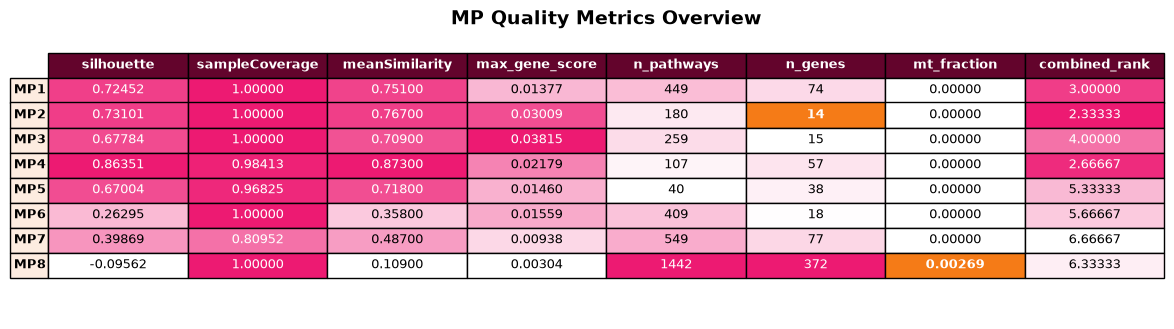

In [55]:
INFERNO_PINK = "#ed1a72"
HEADER_COLOR = "#63042c"
YELLOW = "#ffd23f" # not used
INDEX_COLOR = "#fdece0"
OUTLIER_COLOR = "#f57b17"  # or #82042a
cmap = mcolors.LinearSegmentedColormap.from_list("pastel_to_pink", ["#ffffff", INFERNO_PINK])

fig, ax = plt.subplots(figsize=(12, max(4, len(table_df) * 0.4)))
ax.axis("off")

int_cols = ["n_pathways", "n_genes"]
float_cols = [c for c in display_cols if c not in int_cols]

table_df = summary[display_cols].copy()

cell_text = table_df.copy()

for col in float_cols:
    cell_text[col] = table_df[col].apply(lambda x: f"{x:.5f}")

for col in int_cols:
    cell_text[col] = table_df[col].apply(lambda x: f"{int(round(x))}")

tbl = ax.table(
    cellText=cell_text.values,
    rowLabels=table_df.index,
    colLabels=table_df.columns,
    cellLoc="center",
    loc="center"
)

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor(HEADER_COLOR)
        cell.set_text_props(color="white", weight="bold")
    elif col == -1:
        cell.set_facecolor(INDEX_COLOR)
        cell.set_text_props(weight="bold")
    else:
        col_name = table_df.columns[col]
        mp_name = table_df.index[row - 1]
        val = norm_df.loc[mp_name, col_name]
        cell.set_facecolor(cmap(val))
        cell.set_text_props(color="white" if val > 0.6 else "black")

        if col_name == "mt_fraction" and table_df.loc[mp_name, col_name] > 0:
            cell.set_facecolor(OUTLIER_COLOR)
            cell.set_text_props(color="white", weight="bold")
        if col_name == "n_pathways" and table_df.loc[mp_name, col_name] == 0:
            cell.set_facecolor(OUTLIER_COLOR)
            cell.set_text_props(color="white", weight="bold")
        if col_name == "n_genes" and (table_df.loc[mp_name, col_name] < 15 or table_df.loc[mp_name, col_name] > 1000):
            cell.set_facecolor(OUTLIER_COLOR)
            cell.set_text_props(color="white", weight="bold")

tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.5)

plt.title("MP Quality Metrics Overview", fontsize=14, fontweight="bold", y=0.93)
plt.savefig(os.path.join(OUT_DIR, "09_05_mp_quality_overview_table.pdf"), bbox_inches="tight")
plt.show()
plt.close()

In [47]:
mt_rows = adata.var[adata.var['feature_name'].astype(str).str.startswith('MT-')]
print(mt_rows.index.tolist())         # what does var.index look like for these 13 rows?
print(mt_rows['feature_name'].tolist())  # should be the MT- symbols

['MT-ND1', 'MT-ND2', 'MT-CO1', 'MT-CO2', 'MT-ATP8', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND4L', 'MT-ND4', 'MT-ND5', 'MT-ND6', 'MT-CYB']
['MT-ND1', 'MT-ND2', 'MT-CO1', 'MT-CO2', 'MT-ATP8', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND4L', 'MT-ND4', 'MT-ND5', 'MT-ND6', 'MT-CYB']


In [45]:
# how many var.index entries actually look like Ensembl IDs?
is_ensembl = adata.var.index.str.startswith("ENSG")
print(is_ensembl.sum(), "/", len(adata.var), "rows have Ensembl-style index")

# for those Ensembl-indexed rows, does feature_name look populated and sane?
print(adata.var.loc[is_ensembl, 'feature_name'].head(10))
print(adata.var.loc[is_ensembl, 'feature_name'].isna().sum())

# does mp_dict's specific ENSG ids actually exist in var.index at all?
test_genes = mp_dict["MP8"].index.tolist()[:5]
print([g in adata.var.index for g in test_genes])

6099 / 32338 rows have Ensembl-style index
feature_name
ENSG00000239945    ENSG00000239945
ENSG00000239906    ENSG00000239906
ENSG00000241599    ENSG00000241599
ENSG00000236601    ENSG00000236601
ENSG00000235146    ENSG00000235146
ENSG00000229905    ENSG00000229905
ENSG00000272438    ENSG00000272438
ENSG00000272512    ENSG00000272512
ENSG00000224969    ENSG00000224969
ENSG00000273443    ENSG00000273443
Name: feature_name, dtype: string
0
[False, False, False, False, False]
